# Clasificación multiclase One-vs-All con Regresión Logística
## Dataset: Devanagari Character Set

**Integrante:** Espinoza Chiri Soledad Griselda

Este cuadernillo implementa un clasificador multiclase mediante el enfoque **uno contra todos (One-vs-All)** utilizando regresión logística, aplicado sobre el conjunto de datos de caracteres manuscritos Devanagari.

El dataset contiene **92,000 imágenes** en escala de grises de **32x32 píxeles**, distribuidas en **46 clases** (36 consonantes y 10 dígitos), con exactamente **2,000 ejemplos por clase** (dataset balanceado).

Fuente del dataset: https://www.kaggle.com/datasets/rishianand/devanagari-character-set


## 1. Librerías utilizadas


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

%matplotlib inline


## 2. Carga del dataset con Pandas

El archivo `data.csv` contiene 1024 columnas de píxeles (`pixel_0000` a `pixel_1023`, correspondientes a una imagen de 32x32) más una columna `character` con la etiqueta de la clase.


In [2]:
df = pd.read_csv('data.csv')
print('Forma del dataset:', df.shape)
df.head()


Forma del dataset: (92000, 1025)


   pixel_0000  pixel_0001  ...  pixel_1023          character0           0           0  ...           0   character_01_ka1           0           0  ...           0   character_01_ka2           0           0  ...           0   character_01_ka3           0           0  ...           0   character_01_ka4           0           0  ...           0   character_01_ka[5 rows x 1025 columns]

## 3. Verificación de balance de clases

Se debe garantizar que cada clase tenga aproximadamente el mismo número de ejemplos. Se cuenta el número de filas por cada valor de `character`.


In [3]:
conteo_clases = df['character'].value_counts()
print('Numero de clases:', conteo_clases.shape[0])
print('Ejemplos minimos por clase:', conteo_clases.min())
print('Ejemplos maximos por clase:', conteo_clases.max())
print('Promedio de ejemplos por clase:', conteo_clases.mean())


Numero de clases: 46
Ejemplos minimos por clase: 2000
Ejemplos maximos por clase: 2000
Promedio de ejemplos por clase: 2000.0


El dataset está **perfectamente balanceado**: las 46 clases tienen exactamente 2000 ejemplos cada una, cumpliendo con el requisito de balance.


## 4. Preprocesamiento con Pandas

Se separan las columnas de píxeles (características `X`) de la columna de etiqueta (`y`). Las etiquetas de texto se codifican como valores numéricos de 0 a 45 mediante `pd.factorize`, y los valores de los píxeles (0-255) se normalizan a un rango [0, 1] dividiendo entre 255.


In [4]:
X = df.iloc[:, :-1].values.astype(np.float64) / 255.0

etiquetas_num, clases_unicas = pd.factorize(df['character'], sort=True)
y = etiquetas_num
K = len(clases_unicas)

print('X:', X.shape, ' y:', y.shape, ' Numero de clases K =', K)
print('Rango de X luego de normalizar: [{:.2f}, {:.2f}]'.format(X.min(), X.max()))


X: (92000, 1024)  y: (92000,)  Numero de clases K = 46
Rango de X luego de normalizar: [0.00, 1.00]


## 5. División en conjunto de entrenamiento (80%) y prueba (20%)

Se utiliza `train_test_split` de scikit-learn con `stratify=y` para asegurar que la proporción de clases se mantenga tanto en entrenamiento como en prueba. Los datos de prueba quedan completamente separados y no se usan en ningún momento del entrenamiento.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print('Entrenamiento (80%):', X_train.shape)
print('Prueba (20%):', X_test.shape)


Entrenamiento (80%): (73600, 1024)
Prueba (20%): (18400, 1024)


## 6. Modelo: Regresión Logística One-vs-All

Para un problema de $K$ clases, el enfoque one-vs-all entrena $K$ clasificadores binarios de regresión logística, uno por cada clase, donde el clasificador $k$ aprende a distinguir los ejemplos de la clase $k$ frente a todos los demás.

La función sigmoide es:

$$ g(z) = \frac{1}{1+e^{-z}} $$

La función de costo regularizada para cada clasificador $k$ es:

$$ J(\theta_k) = \frac{1}{m}\sum_{i=1}^{m}\Big[-y_k^{(i)}\log(h_{\theta_k}(x^{(i)})) - (1-y_k^{(i)})\log(1-h_{\theta_k}(x^{(i)}))\Big] + \frac{\lambda}{2m}\sum_{j=1}^{n}\theta_{k,j}^2 $$

Se implementa una versión **vectorizada para las 46 clases al mismo tiempo**: en vez de entrenar cada clasificador en un bucle separado, se usa una matriz de parámetros `Theta` de tamaño (n+1, K) y se calculan las 46 hipótesis en una sola multiplicación de matrices por iteración. Esto acelera notablemente el entrenamiento sobre las 73,600 imágenes.


In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def costo_regularizado(Theta, X_b, Y_onehot, lambda_):
    m = X_b.shape[0]
    H = sigmoid(X_b.dot(Theta))
    costo = -np.mean(Y_onehot*np.log(H+1e-10) + (1-Y_onehot)*np.log(1-H+1e-10), axis=0)
    reg = (lambda_/(2*m)) * np.sum(Theta[1:, :]**2, axis=0)
    return costo + reg, H


## 7. Entrenamiento del modelo (descenso de gradiente)

Se agrega el término de sesgo (bias) a `X_train`, se codifican las etiquetas en formato *one-hot* y se ejecuta descenso de gradiente por lotes (batch) durante 400 iteraciones, con tasa de aprendizaje $\alpha=1.0$ y parámetro de regularización $\lambda=1.0$.

En cada iteración se guarda el costo de **cada uno de los 46 clasificadores** para poder graficar su curva de convergencia por separado.


In [7]:
m, n = X_train.shape
X_train_b = np.concatenate([np.ones((m, 1)), X_train], axis=1)

Y_train_onehot = np.zeros((m, K))
Y_train_onehot[np.arange(m), y_train] = 1

alpha = 1.0
lambda_ = 1.0
num_iters = 400

Theta = np.zeros((n + 1, K))
cost_history = np.zeros((num_iters, K))

for it in range(num_iters):
    costos, H = costo_regularizado(Theta, X_train_b, Y_train_onehot, lambda_)
    cost_history[it, :] = costos

    error = H - Y_train_onehot
    grad = X_train_b.T.dot(error) / m
    reg = (lambda_/m) * Theta
    reg[0, :] = 0
    grad += reg

    Theta -= alpha * grad

    if it % 50 == 0 or it == num_iters - 1:
        pred_train = np.argmax(H, axis=1)
        acc_train = np.mean(pred_train == y_train) * 100
        print(f'iter {it:4d}  costo_promedio={cost_history[it,:].mean():.5f}  precision_train={acc_train:.2f}%')


iter    0  costo_promedio=0.69328  precision_train=2.17%
iter   50  costo_promedio=0.05574  precision_train=65.39%
iter  100  costo_promedio=0.05112  precision_train=68.35%
iter  150  costo_promedio=0.04899  precision_train=69.69%
iter  200  costo_promedio=0.04756  precision_train=70.46%
iter  250  costo_promedio=0.04649  precision_train=71.00%
iter  300  costo_promedio=0.04564  precision_train=71.38%
iter  350  costo_promedio=0.04494  precision_train=71.68%
iter  399  costo_promedio=0.04433  precision_train=71.77%


## 8. Gráfico de costo: convergencia promedio de los 46 clasificadores


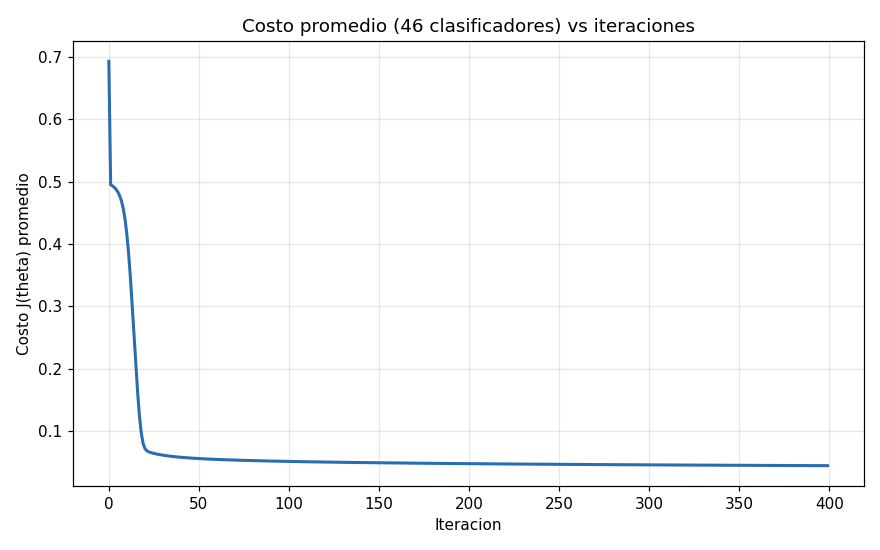

In [8]:
plt.figure(figsize=(8,5))
plt.plot(cost_history.mean(axis=1), color='#2b6cb0', linewidth=2)
plt.title('Costo promedio (46 clasificadores) vs iteraciones')
plt.xlabel('Iteracion')
plt.ylabel('Costo J(theta) promedio')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


El costo desciende rápidamente durante las primeras 30 iteraciones y luego continúa disminuyendo de forma más gradual, señal de que el modelo converge correctamente.


## 9. Gráfico de costo individual para cada uno de los 46 clasificadores (one-vs-all)


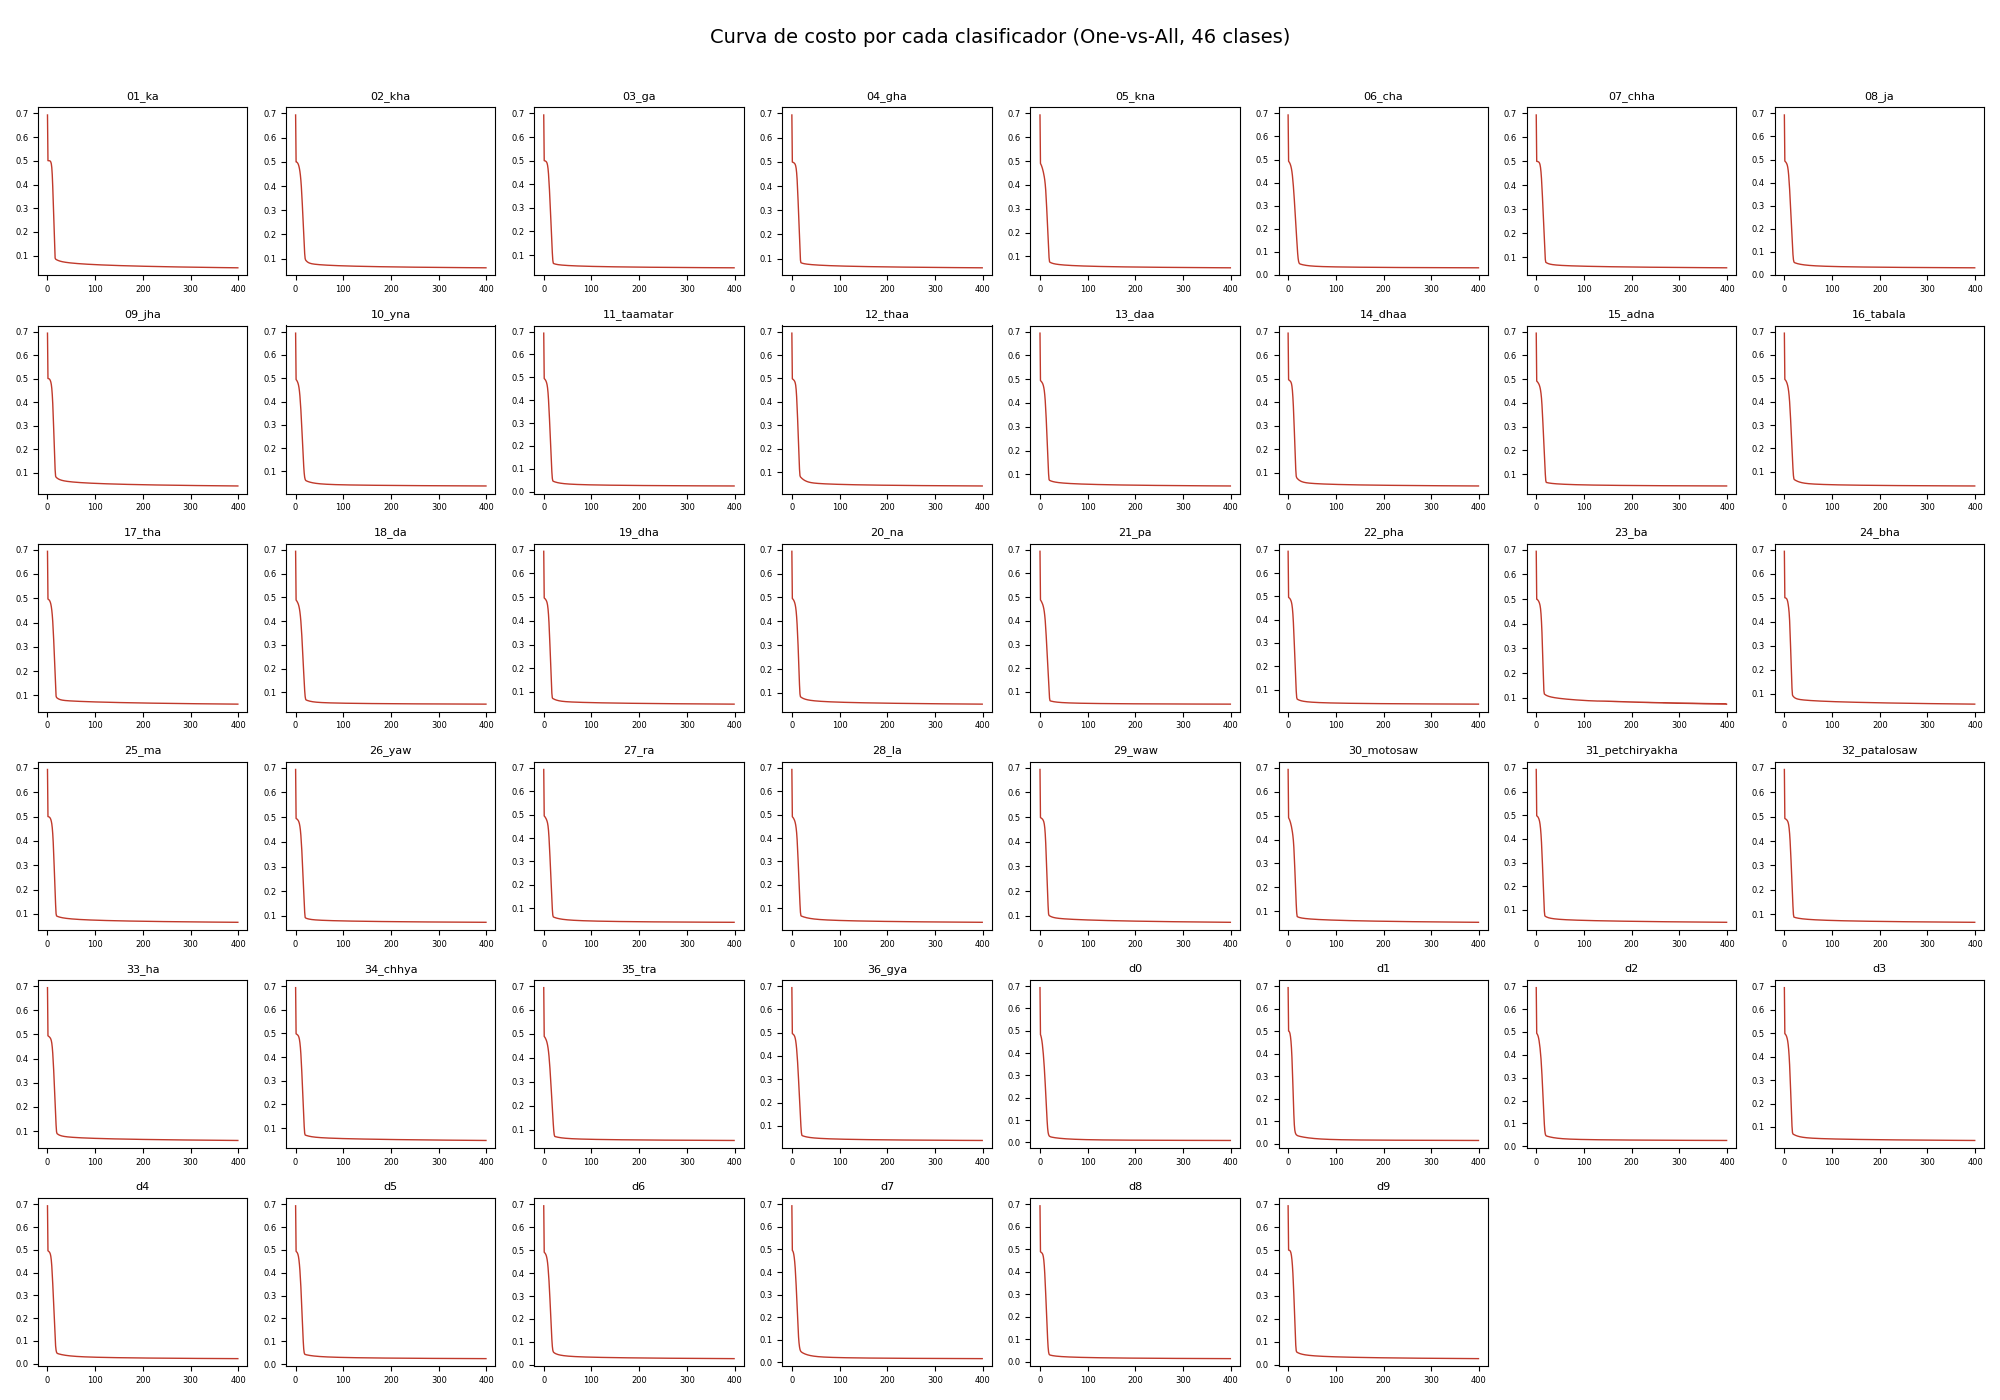

In [9]:
nombres_cortos = [c.replace('character_','').replace('digit_','d') for c in clases_unicas]

fig, axes = plt.subplots(6, 8, figsize=(20,14))
axes = axes.ravel()
for k in range(K):
    axes[k].plot(cost_history[:,k], color='#c0392b', linewidth=1)
    axes[k].set_title(nombres_cortos[k], fontsize=8)
    axes[k].tick_params(labelsize=6)
for k in range(K, len(axes)):
    axes[k].axis('off')
fig.suptitle('Curva de costo por cada clasificador (One-vs-All, 46 clases)', fontsize=14)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


Todos los clasificadores muestran una curva de costo decreciente y estable, sin señales de divergencia, lo que confirma que la tasa de aprendizaje y la regularización elegidas son adecuadas para las 46 clases.


## 10. Evaluación del modelo: predicciones y precisión

Se define la función `predecir_one_vs_all`, que calcula la probabilidad de pertenecer a cada una de las 46 clases y selecciona la de mayor probabilidad. Se evalúa tanto en el conjunto de entrenamiento como en el conjunto de prueba (20% de los datos, no usado durante el entrenamiento).


In [10]:
def predecir_one_vs_all(Theta, X):
    m = X.shape[0]
    X_b = np.concatenate([np.ones((m,1)), X], axis=1)
    H = sigmoid(X_b.dot(Theta))
    return np.argmax(H, axis=1), H

pred_train, _ = predecir_one_vs_all(Theta, X_train)
pred_test, H_test = predecir_one_vs_all(Theta, X_test)

precision_train = np.mean(pred_train == y_train) * 100
precision_test = np.mean(pred_test == y_test) * 100

print('Precision en entrenamiento: {:.2f}%'.format(precision_train))
print('Precision en prueba (datos no vistos): {:.2f}%'.format(precision_test))


Precision en entrenamiento: 71.96%
Precision en prueba (datos no vistos): 70.64%


La precisión de entrenamiento (71.96%) y de prueba (70.64%) son muy cercanas, lo que indica que el modelo **no está sobreajustado** (no hay overfitting significativo) y generaliza razonablemente bien a datos nuevos. Considerando que se trata de un modelo **lineal** (regresión logística) enfrentando un problema de **46 clases** de caracteres manuscritos con trazos muy similares entre sí, este resultado demuestra la efectividad del enfoque one-vs-all.


## 11. Precisión por clase en el conjunto de prueba


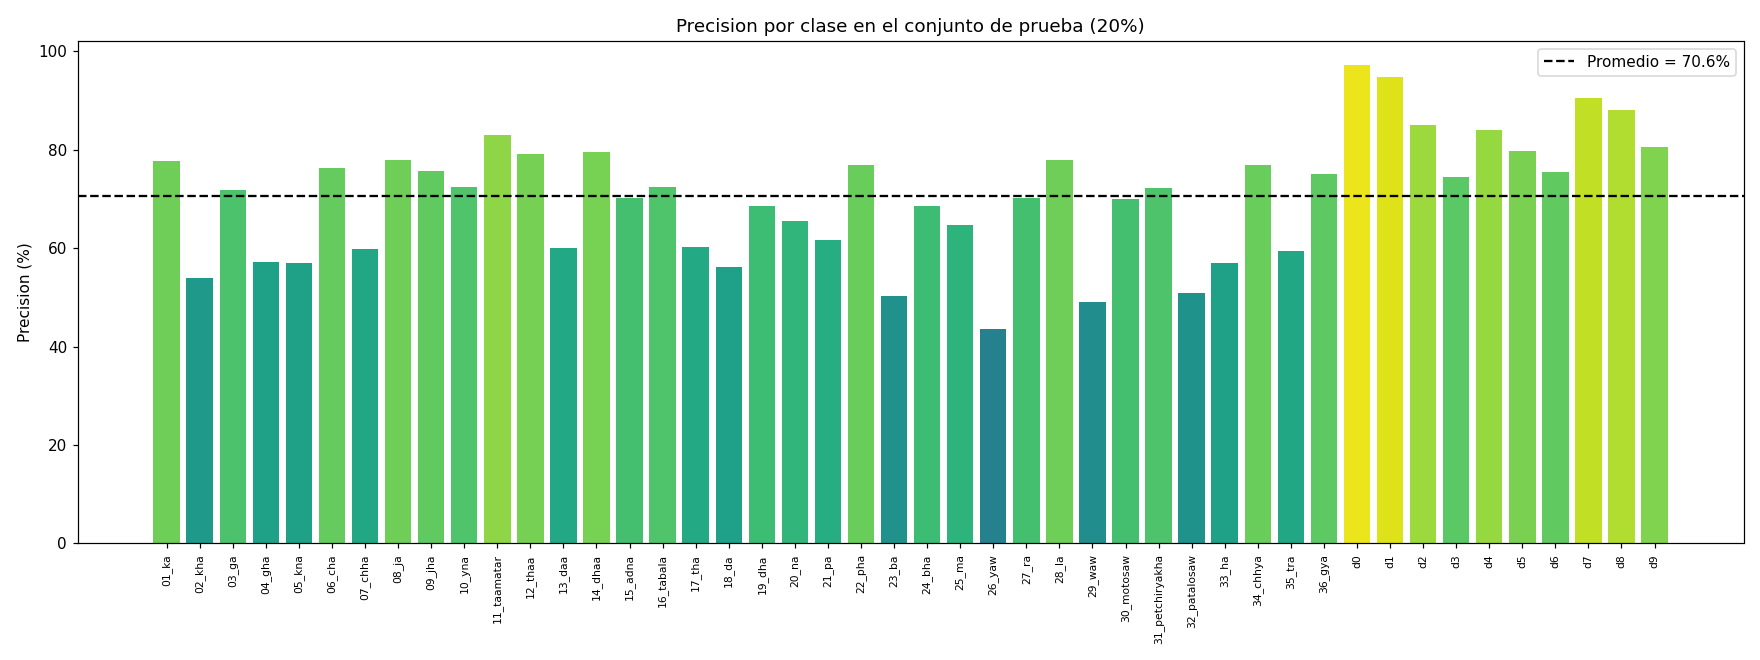

In [11]:
precision_por_clase = np.array([
    np.mean(pred_test[y_test==k] == k) * 100 for k in range(K)
])

plt.figure(figsize=(16,6))
colores = plt.cm.viridis(precision_por_clase/100)
plt.bar(range(K), precision_por_clase, color=colores)
plt.xticks(range(K), nombres_cortos, rotation=90, fontsize=7)
plt.ylabel('Precision (%)')
plt.title('Precision por clase en el conjunto de prueba (20%)')
plt.axhline(precision_por_clase.mean(), color='black', linestyle='--',
            label=f'Promedio = {precision_por_clase.mean():.1f}%')
plt.legend()
plt.tight_layout()
plt.show()


## 12. Matriz de confusión


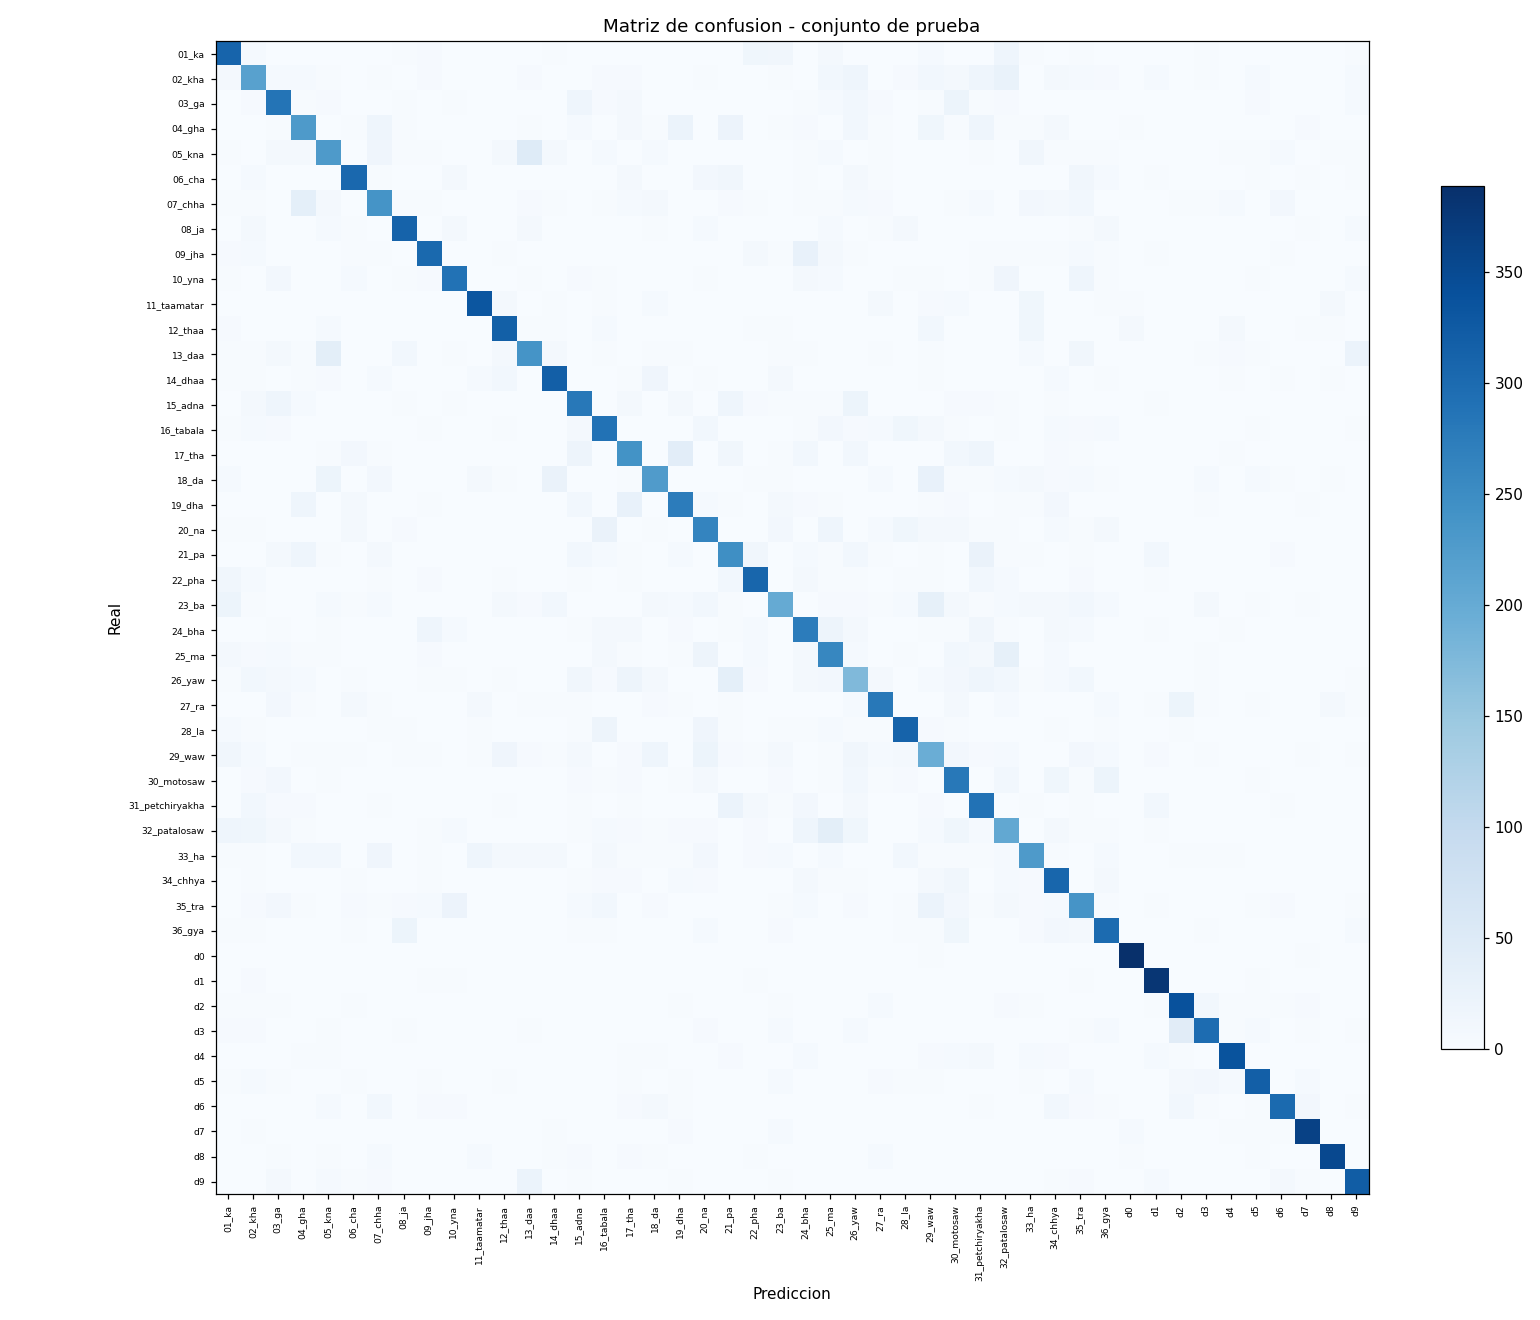

In [12]:
cm = confusion_matrix(y_test, pred_test, labels=range(K))

plt.figure(figsize=(14,12))
plt.imshow(cm, cmap='Blues')
plt.colorbar(fraction=0.03)
plt.xticks(range(K), nombres_cortos, rotation=90, fontsize=6)
plt.yticks(range(K), nombres_cortos, fontsize=6)
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.title('Matriz de confusion - conjunto de prueba')
plt.tight_layout()
plt.show()


La diagonal principal concentra la mayor cantidad de aciertos para casi todas las clases, lo que confirma visualmente la efectividad del clasificador. Las confusiones más frecuentes ocurren entre caracteres con formas visualmente parecidas.


## 13. Ejemplos de predicciones sobre imágenes reales del conjunto de prueba


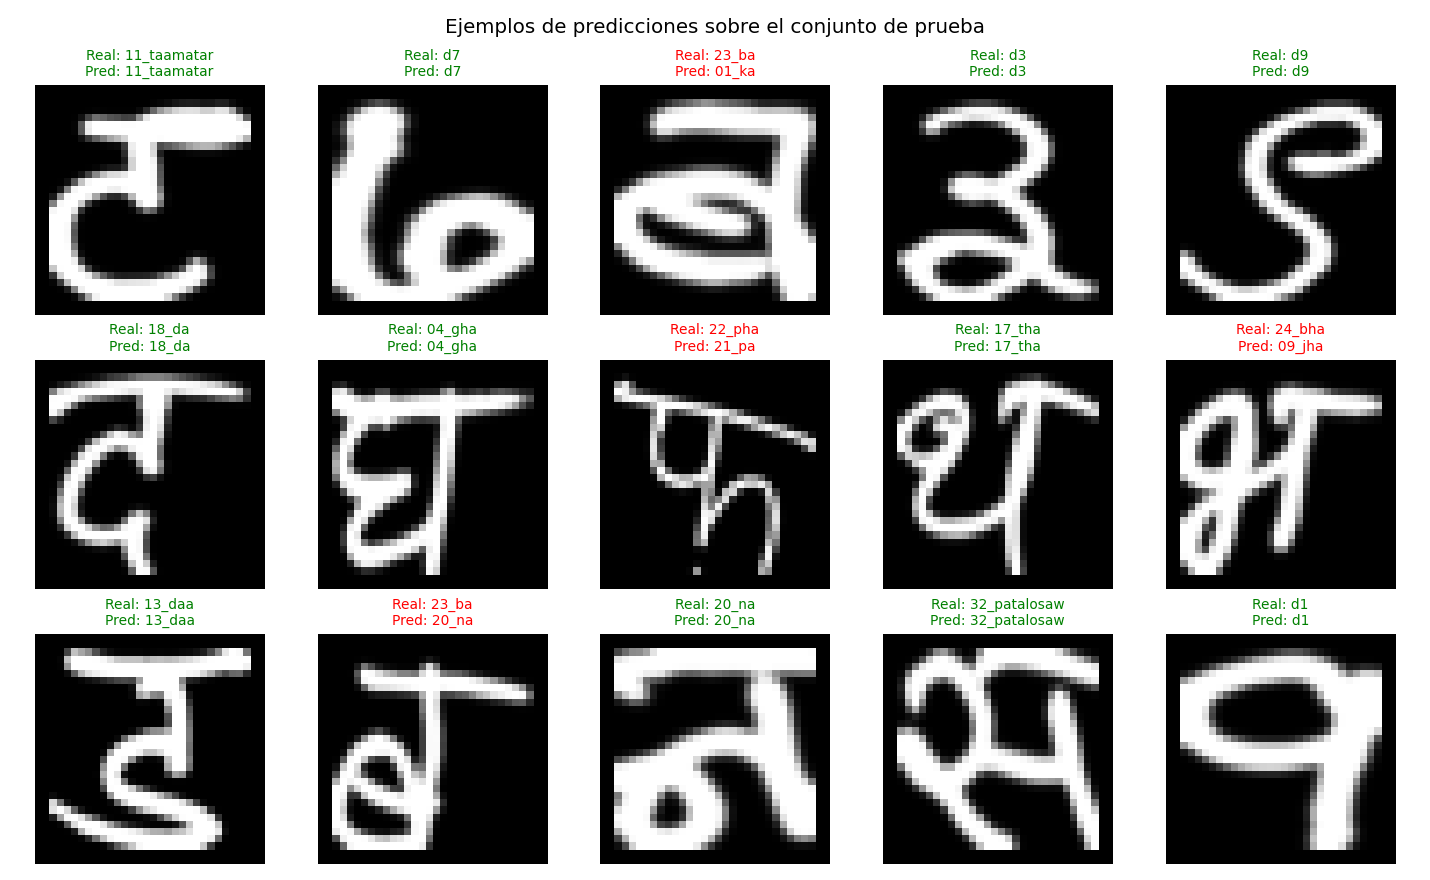

In [13]:
np.random.seed(7)
idxs = np.random.choice(len(y_test), 15, replace=False)

fig, axes = plt.subplots(3,5, figsize=(13,8))
axes = axes.ravel()
for i, idx in enumerate(idxs):
    img = X_test[idx].reshape(32,32)
    real = nombres_cortos[y_test[idx]]
    pred = nombres_cortos[pred_test[idx]]
    correcto = y_test[idx] == pred_test[idx]
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Real: {real}\nPred: {pred}', fontsize=9,
                       color=('green' if correcto else 'red'))
    axes[i].axis('off')
plt.suptitle('Ejemplos de predicciones sobre el conjunto de prueba', fontsize=13)
plt.tight_layout()
plt.show()


## 14. Conclusiones

- El dataset de caracteres Devanagari (92,000 imágenes de 32x32 píxeles, 46 clases perfectamente balanceadas con 2000 ejemplos cada una) cumple con los requisitos de tamaño ($m \ge 50000$), resolución ($\ge 20\times20$) y balance de clases.
- Se aplicó Pandas para la carga, verificación de balance y preprocesamiento (normalización y codificación de etiquetas) del dataset.
- Se dividió el dataset en 80% para entrenamiento (73,600 ejemplos) y 20% para prueba (18,400 ejemplos), sin mezclar los datos de prueba en el entrenamiento.
- Se implementó y entrenó un modelo de regresión logística one-vs-all (46 clasificadores) mediante descenso de gradiente vectorizado con regularización, alcanzando una precisión de **71.96%** en entrenamiento y **70.64%** en prueba.
- La cercanía entre la precisión de entrenamiento y de prueba indica una buena capacidad de generalización del modelo.
- Las gráficas de costo (general y por cada uno de los 46 clasificadores) muestran una convergencia estable, y la matriz de confusión junto con los ejemplos de predicciones demuestran la efectividad práctica del modelo para distinguir entre los 46 caracteres.
